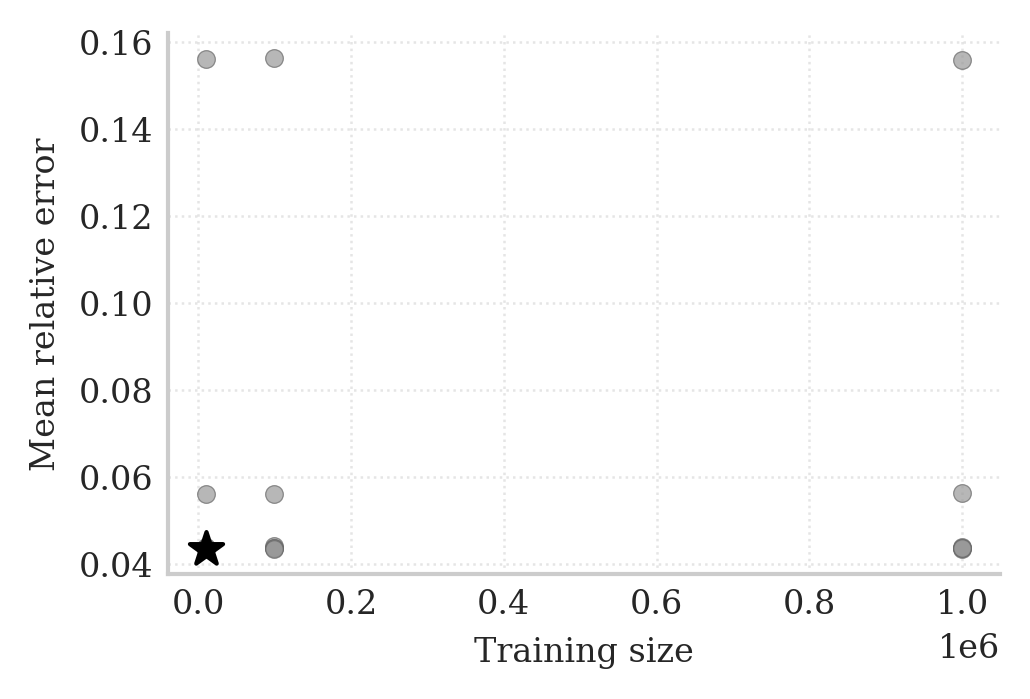

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# --- Load data ---
df = pd.read_csv("/data/cpanourg/2-hdvc/results/relerr/deep_RaBitQ_adc_vs_exact_eval.csv")

# --- Find best configuration (lowest mean error) ---
best = df.loc[df["rel_error_mean"].idxmin()]

# --- Style (paper-quality minimalist) ---
plt.rcParams.update({
    "figure.dpi": 300,
    "savefig.dpi": 300,
    "font.size": 8,
    "font.family": "serif",
    "axes.labelsize": 8,
    "axes.titlesize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

# --- Scatter plot: Mean Relative Error vs Training Size ---
fig, ax = plt.subplots(figsize=(3.3, 2.2))

# Plot all experiments as light gray dots
ax.scatter(
    df["train_size"], df["rel_error_mean"],
    s=18, color="0.6", alpha=0.7, linewidths=0.3, edgecolors="0.4"
)

# Highlight best configuration as a black star
ax.scatter(
    best["train_size"], best["rel_error_mean"],
    s=70, marker="*", color="black", edgecolors="black", zorder=3
)

# --- Labels and grid ---
ax.set_xlabel("Training size")
ax.set_ylabel("Mean relative error")

ax.grid(True, linestyle=":", linewidth=0.6, alpha=0.5)

# Format x-axis as integer (e.g., 10 000 → 1e4)
ax.ticklabel_format(style='sci', axis='x', scilimits=(4,6))

plt.tight_layout(pad=0.3)
from pathlib import Path
fig_dir = Path("/home/cpanourg/projects/2-hdvc/notebooks/general_results/figures")
fig_dir.mkdir(parents=True, exist_ok=True)
plt.savefig(fig_dir / "relerr_vs_training_size.pdf", bbox_inches="tight")
plt.show()


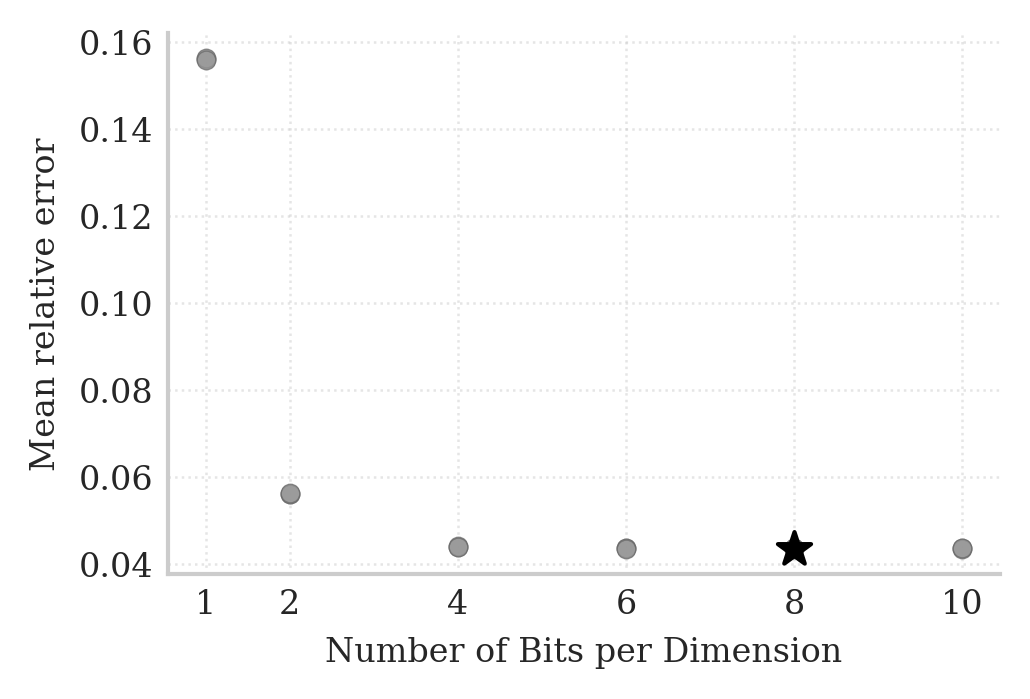

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# --- Load data ---
df = pd.read_csv("/data/cpanourg/2-hdvc/results/relerr/deep_RaBitQ_adc_vs_exact_eval.csv")

# --- Find best configuration (lowest mean error) ---
best = df.loc[df["rel_error_mean"].idxmin()]

# --- Style (consistent with previous plot) ---
plt.rcParams.update({
    "figure.dpi": 300,
    "savefig.dpi": 300,
    "font.size": 8,
    "font.family": "serif",
    "axes.labelsize": 8,
    "axes.titlesize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

# --- Scatter plot: Mean Relative Error vs Subquantizers ---
fig, ax = plt.subplots(figsize=(3.3, 2.2))

# Plot all configurations as gray points
ax.scatter(
    df["bits_per_dim"], df["rel_error_mean"],
    s=20, color="0.6", alpha=0.7, linewidths=0.3, edgecolors="0.4"
)

# Highlight best configuration as a black star
ax.scatter(
    best["bits_per_dim"], best["rel_error_mean"],
    s=70, marker="*", color="black", edgecolors="black", zorder=3
)

# --- Labels and grid ---
# ax.set_title("Mean Relative Error vs Number of Subquantizers", pad=3)
ax.set_xlabel("Number of Bits per Dimension")
ax.set_ylabel("Mean relative error")
ax.grid(True, linestyle=":", linewidth=0.6, alpha=0.5)

# Make x-axis integer ticks
ax.set_xticks(sorted(df["bits_per_dim"].unique()))

plt.tight_layout(pad=0.3)
from pathlib import Path
fig_dir = Path("/home/cpanourg/projects/2-hdvc/notebooks/general_results/figures")
fig_dir.mkdir(parents=True, exist_ok=True)
plt.savefig(fig_dir / "relerr_vs_subquantizers.pdf", bbox_inches="tight")
plt.show()


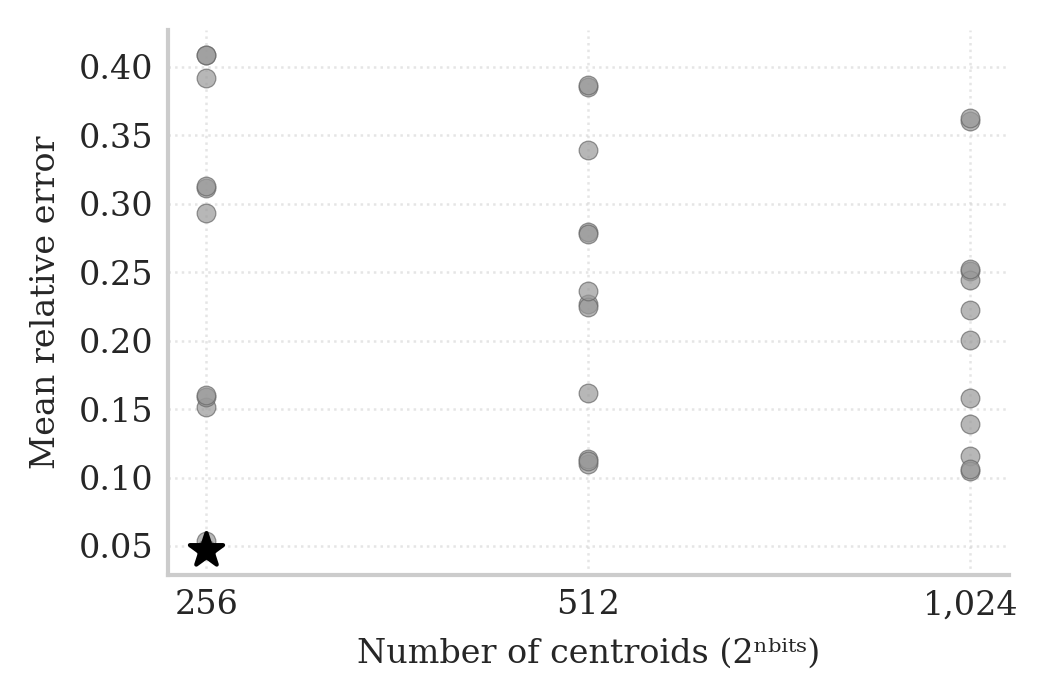

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# --- Load data ---
df = pd.read_csv("/data/cpanourg/2-hdvc/results/relerr/deep_PQ_adc_vs_exact_eval.csv")

# --- Compute number of centroids = 2^nbits ---
df["num_centroids"] = 2 ** df["nbits"]

# --- Find best configuration (lowest mean error) ---
best = df.loc[df["rel_error_mean"].idxmin()]

# --- Style (consistent with previous plots) ---
plt.rcParams.update({
    "figure.dpi": 300,
    "savefig.dpi": 300,
    "font.size": 8,
    "font.family": "serif",
    "axes.labelsize": 8,
    "axes.titlesize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

# --- Scatter plot: Mean Relative Error vs Number of Centroids ---
fig, ax = plt.subplots(figsize=(3.3, 2.2))

# Plot all configurations as gray points
ax.scatter(
    df["num_centroids"], df["rel_error_mean"],
    s=20, color="0.6", alpha=0.7, linewidths=0.3, edgecolors="0.4"
)

# Highlight best configuration as a black star
ax.scatter(
    best["num_centroids"], best["rel_error_mean"],
    s=70, marker="*", color="black", edgecolors="black", zorder=3
)

# --- Labels and grid ---
# ax.set_title("Mean Relative Error vs Number of Centroids", pad=3)
ax.set_xlabel("Number of centroids (2ⁿᵇⁱᵗˢ)")
ax.set_ylabel("Mean relative error")
ax.grid(True, linestyle=":", linewidth=0.6, alpha=0.5)

# Use log scale if wide range (since 2^nbits grows exponentially)
ax.set_xscale("log", base=2)
ax.set_xticks(df["num_centroids"].unique())
ax.get_xaxis().set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))

plt.tight_layout(pad=0.3)
from pathlib import Path
fig_dir = Path("/home/cpanourg/projects/2-hdvc/notebooks/general_results/figures")
fig_dir.mkdir(parents=True, exist_ok=True)
plt.savefig(fig_dir / "relerr_vs_num_centroids.pdf", bbox_inches="tight")
plt.show()


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
from pathlib import Path
import glob

# --- Configuration ---
RESULTS_DIR = "/data/cpanourg/2-hdvc/results/relerr/"
OUTPUT_DIR = Path("/home/cpanourg/projects/2-hdvc/notebooks/general_results/figures/second_hp_test")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)  # Create directory if it doesn't exist

# --- Style (paper-quality minimalist) ---
plt.rcParams.update({
    "figure.dpi": 300,
    "savefig.dpi": 300,
    "font.size": 8,
    "font.family": "serif",
    "axes.labelsize": 8,
    "axes.titlesize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

# --- Find all CSV files ---
csv_files = glob.glob(f"{RESULTS_DIR}/deep_*_adc_vs_exact_eval.csv")
methods = {}
for csv_file in csv_files:
    method_name = Path(csv_file).stem.replace("deep_", "").replace("_adc_vs_exact_eval", "")
    methods[method_name] = csv_file

print(f"Found methods: {list(methods.keys())}")

# --- Define x-axis variables for each method ---
x_axis_configs = {
    "PQ": ["train_size", "n_subquantizers", "nbits", "bits_per_vector"],
    "OPQ": ["train_size", "n_subquantizers", "nbits", "bits_per_vector"],
    "LSQpp": ["train_size", "n_subquantizers", "nbits", "bits_per_vector"],
    "RaBitQ": ["train_size", "bits_per_dim", "bits_per_vector"],
    "VAQ": ["train_size", "n_subquantizers", "bits_per_vector", "min_bits", "max_bits"],
}

# --- X-axis label mapping ---
x_labels = {
    "train_size": "Training size",
    "n_subquantizers": "Number of subquantizers",
    "nbits": "Bits per subspace",
    "bits_per_vector": "Bits per vector",
    "bits_per_dim": "Bits per dimension",
    "min_bits": "Minimum bits per subspace",
    "max_bits": "Maximum bits per subspace",
}

# --- Function to perform significance test ---
def perform_significance_test(x, y):
    """
    Perform Pearson correlation test and return p-value and sample size.
    
    Pearson correlation is valid for testing linear relationships between continuous variables.
    It tests H0: correlation = 0 (no linear relationship) vs H1: correlation != 0.
    Returns p-value < 0.05 indicates significant linear relationship.
    """
    # Remove NaN values
    mask = ~(np.isnan(x) | np.isnan(y))
    x_clean = np.array(x)[mask]
    y_clean = np.array(y)[mask]
    
    if len(x_clean) < 3:
        return None, None
    
    # Check if either variable is constant (correlation undefined)
    if np.std(x_clean) == 0 or np.std(y_clean) == 0:
        return None, None
    
    # Pearson correlation test
    try:
        corr, p_value = stats.pearsonr(x_clean, y_clean)
        return p_value, len(x_clean)
    except:
        return None, None

# --- Generate plots for each method ---
for method_name, csv_file in methods.items():
    print(f"\nProcessing {method_name}...")
    df = pd.read_csv(csv_file)
    
    # Get x-axis variables for this method
    method_x_vars = x_axis_configs.get(method_name, ["train_size", "bits_per_vector"])
    
    # Filter to only variables that exist in the dataframe
    available_x_vars = [x for x in method_x_vars if x in df.columns]
    
    for x_var in available_x_vars:
        # Skip if no valid data
        if df[x_var].isna().all():
            continue
        
        # Remove rows with NaN in x or y variables
        df_clean = df[[x_var, "rel_error_mean", "rel_error_std"]].dropna()
        
        if len(df_clean) < 2:
            continue
        
        # --- Plot 1: Mean Relative Error ---
        fig, ax = plt.subplots(figsize=(3.3, 2.2))
        
        # Scatter plot
        ax.scatter(
            df_clean[x_var], df_clean["rel_error_mean"],
            s=20, color="0.6", alpha=0.7, linewidths=0.3, edgecolors="0.4"
        )
        
        # Highlight best configuration
        best_idx = df_clean["rel_error_mean"].idxmin()
        best = df_clean.loc[best_idx]
        ax.scatter(
            best[x_var], best["rel_error_mean"],
            s=70, marker="*", color="black", edgecolors="black", zorder=3
        )
        
        # Perform significance test
        p_val, n_samples = perform_significance_test(df_clean[x_var], df_clean["rel_error_mean"])
        
        # Add significance test result to plot (top-right corner to avoid overlapping points)
        if p_val is not None:
            sig_text = "significant" if p_val < 0.05 else "not significant"
            test_text = f"p={p_val:.3e} ({sig_text})\nn={n_samples}"
            ax.text(0.98, 0.98, test_text, transform=ax.transAxes,
                   fontsize=7, verticalalignment='top', horizontalalignment='right',
                   bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
        
        # Labels and formatting
        ax.set_xlabel(x_labels.get(x_var, x_var))
        ax.set_ylabel("Mean relative error")
        ax.grid(True, linestyle=":", linewidth=0.6, alpha=0.5)
        
        # Format x-axis
        if x_var == "train_size":
            ax.ticklabel_format(style='sci', axis='x', scilimits=(4,6))
        elif x_var in ["nbits", "n_subquantizers", "bits_per_dim", "min_bits", "max_bits"]:
            ax.set_xticks(sorted(df_clean[x_var].unique()))
        
        plt.tight_layout(pad=0.3)
        
        # Save figure
        filename = f"{x_var}_{method_name}_mean_rel_error.pdf"
        filepath = OUTPUT_DIR / filename
        plt.savefig(filepath, bbox_inches="tight")
        print(f"  Saved: {filepath}")
        plt.close()
        
        # --- Plot 2: Standard Deviation of Relative Error ---
        fig, ax = plt.subplots(figsize=(3.3, 2.2))
        
        # Scatter plot
        ax.scatter(
            df_clean[x_var], df_clean["rel_error_std"],
            s=20, color="0.6", alpha=0.7, linewidths=0.3, edgecolors="0.4"
        )
        
        # Highlight configuration with minimum std (associated with best mean)
        best_idx = df_clean["rel_error_mean"].idxmin()
        best = df_clean.loc[best_idx]
        ax.scatter(
            best[x_var], best["rel_error_std"],
            s=70, marker="*", color="black", edgecolors="black", zorder=3
        )
        
        # Perform significance test
        p_val, n_samples = perform_significance_test(df_clean[x_var], df_clean["rel_error_std"])
        
        # Add significance test result to plot (top-right corner to avoid overlapping points)
        if p_val is not None:
            sig_text = "significant" if p_val < 0.05 else "not significant"
            test_text = f"p={p_val:.3e} ({sig_text})\nn={n_samples}"
            ax.text(0.98, 0.98, test_text, transform=ax.transAxes,
                   fontsize=7, verticalalignment='top', horizontalalignment='right',
                   bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
        
        # Labels and formatting
        ax.set_xlabel(x_labels.get(x_var, x_var))
        ax.set_ylabel("Std dev of relative error")
        ax.grid(True, linestyle=":", linewidth=0.6, alpha=0.5)
        
        # Format x-axis
        if x_var == "train_size":
            ax.ticklabel_format(style='sci', axis='x', scilimits=(4,6))
        elif x_var in ["nbits", "n_subquantizers", "bits_per_dim", "min_bits", "max_bits"]:
            ax.set_xticks(sorted(df_clean[x_var].unique()))
        
        plt.tight_layout(pad=0.3)
        
        # Save figure
        filename = f"{x_var}_{method_name}_std_rel_error.pdf"
        filepath = OUTPUT_DIR / filename
        plt.savefig(filepath, bbox_inches="tight")
        print(f"  Saved: {filepath}")
        plt.close()

print("\n✅ All plots generated successfully!")


Found methods: ['PQ']

Processing PQ...
  Saved: /home/cpanourg/projects/2-hdvc/notebooks/general_results/figures/second_hp_test/train_size_PQ_mean_rel_error.pdf
  Saved: /home/cpanourg/projects/2-hdvc/notebooks/general_results/figures/second_hp_test/train_size_PQ_std_rel_error.pdf
  Saved: /home/cpanourg/projects/2-hdvc/notebooks/general_results/figures/second_hp_test/n_subquantizers_PQ_mean_rel_error.pdf
  Saved: /home/cpanourg/projects/2-hdvc/notebooks/general_results/figures/second_hp_test/n_subquantizers_PQ_std_rel_error.pdf
  Saved: /home/cpanourg/projects/2-hdvc/notebooks/general_results/figures/second_hp_test/nbits_PQ_mean_rel_error.pdf
  Saved: /home/cpanourg/projects/2-hdvc/notebooks/general_results/figures/second_hp_test/nbits_PQ_std_rel_error.pdf
  Saved: /home/cpanourg/projects/2-hdvc/notebooks/general_results/figures/second_hp_test/bits_per_vector_PQ_mean_rel_error.pdf
  Saved: /home/cpanourg/projects/2-hdvc/notebooks/general_results/figures/second_hp_test/bits_per_vector

In [4]:
a = np.fromfile('/data/cpanourg/2-hdvc/data/deep1b/deep1b_all.bin', dtype=np.float32)

In [6]:
a.reshape(-1, 96)







array([[ 1.2601726 ,  1.6051961 , -0.6653736 , ...,  0.19918247,
        -1.7065138 , -1.2353626 ],
       [-0.74595517,  0.45815375, -0.64125633, ...,  0.38710845,
         0.1046105 , -0.46917546],
       [ 0.17981829, -0.97230166, -2.3657188 , ...,  0.03767877,
         0.388151  , -0.05372021],
       ...,
       [ 2.1671858 , -0.44879583, -1.0232937 , ..., -0.8092855 ,
        -0.49954745, -1.1575748 ],
       [-0.17669736, -0.7693617 , -1.005811  , ...,  0.94789404,
         0.29668254, -0.16073017],
       [-0.07121839, -1.9118273 ,  0.31957895, ...,  2.564191  ,
         0.60598284, -0.9531451 ]], dtype=float32)

In [ ]:
# ==========================================================
# Load and check z-normalization of DEEP1B data from Yandex
# ==========================================================
import numpy as np
from pathlib import Path
import sys 
sys.path.append('/home/cpanourg/projects/2-hdvc')
from src.utils import read_fbin

# Paths
YANDEX_DIR = Path("/data/cpanourg/2-hdvc/data/yandex/deep1b")
BASE_FILE = YANDEX_DIR / "base.1B.fbin"
LEARN_FILE = YANDEX_DIR / "learn.350M.fbin"
QUERY_FILE = YANDEX_DIR / "query.public.10K.fbin"

print("=" * 60)
print("Loading DEEP1B data from Yandex (10k chunks)")
print("=" * 60)


# Function to check z-normalization on a sample
def check_znorm_sample(data, name="dataset", sample_size=100000, tolerance=0.01):
    """
    Check if vectors are z-normalized (mean ≈ 0, std ≈ 1 per vector).
    
    Parameters:
    - data: numpy array of shape (n_vectors, n_dimensions)
    - name: name of the dataset
    - sample_size: number of vectors to sample for checking
    - tolerance: tolerance for mean (should be close to 0) and std (should be close to 1)
    
    Returns:
    - is_normalized: boolean indicating if data appears z-normalized
    - mean_stats: statistics about means
    - std_stats: statistics about stds
    """
    n_sample = min(sample_size, len(data))
    idx = np.random.choice(len(data), size=n_sample, replace=False)
    sample = data[idx]
    
    # Compute per-vector mean and std
    means = sample.mean(axis=1)
    stds = sample.std(axis=1)
    
    # Aggregate statistics
    mean_of_means = means.mean()
    std_of_means = means.std()
    mean_of_stds = stds.mean()
    std_of_stds = stds.std()
    
    print(f"\n{name} (sampled {n_sample:,} / {len(data):,} vectors)")
    print(f"  Mean per vector: {mean_of_means:.6f} ± {std_of_means:.6f}")
    print(f"  Std per vector:  {mean_of_stds:.6f} ± {std_of_stds:.6f}")
    
    # Check if normalized (mean close to 0, std close to 1)
    is_normalized = (abs(mean_of_means) < tolerance and 
                     abs(mean_of_stds - 1.0) < tolerance)
    
    if is_normalized:
        print(f"  ✓ Data appears to be z-normalized (within tolerance {tolerance})")
    else:
        print(f"  ✗ Data is NOT z-normalized (mean should be ~0, std should be ~1)")
    
    return is_normalized, (mean_of_means, std_of_means), (mean_of_stds, std_of_stds)

# Load data files (10k chunks only)
print("\nLoading base set (10k vectors)...")
base_data = read_fbin(str(BASE_FILE), chunk_size=101_000_000)
print(f"Base data shape: {base_data.shape}")

print("\nLoading learning set (10k vectors)...")
learn_data = read_fbin(str(LEARN_FILE), chunk_size=10000)
print(f"Learn data shape: {learn_data.shape}")

print("\nLoading query set (10k vectors or all if less)...")
query_data = read_fbin(str(QUERY_FILE), chunk_size=10000)
print(f"Query data shape: {query_data.shape}")

# Check z-normalization on the loaded data
print("\n" + "=" * 60)
print("Checking z-normalization")
print("=" * 60)

base_normalized, base_mean_stats, base_std_stats = check_znorm_sample(
    base_data, name="Base set", sample_size=len(base_data)
)

learn_normalized, learn_mean_stats, learn_std_stats = check_znorm_sample(
    learn_data, name="Learning set", sample_size=len(learn_data)
)

query_normalized, query_mean_stats, query_std_stats = check_znorm_sample(
    query_data, name="Query set", sample_size=len(query_data)
)

print("\n" + "=" * 60)
print("Check complete!")
print("=" * 60)

Loading DEEP1B data from Yandex (10k chunks)

Loading base set (10k vectors)...
Base data shape: (101000000, 96)

Loading learning set (10k vectors)...
Learn data shape: (10000, 96)

Loading query set (10k vectors or all if less)...
Query data shape: (10000, 96)

Checking z-normalization


In [2]:
# Load and check z-normalization of DEEP1B data from Yandex
# ==========================================================
import numpy as np
from pathlib import Path
import sys 
sys.path.append('/home/cpanourg/projects/2-hdvc')
from src.utils import read_fbin

# Paths
YANDEX_DIR = Path("/data/cpanourg/2-hdvc/data/yandex/deep1b")
BASE_FILE = YANDEX_DIR / "base.1B.fbin"
LEARN_FILE = YANDEX_DIR / "learn.350M.fbin"
QUERY_FILE = YANDEX_DIR / "query.public.10K.fbin"

print("=" * 60)
print("Loading DEEP1B data from Yandex (10k chunks)")
print("=" * 60)

base_data = read_fbin(str(BASE_FILE), chunk_size=101_000_000)


Loading DEEP1B data from Yandex (10k chunks)


In [3]:
base_data.shape

(101000000, 96)

In [4]:
base_data

array([[ 0.1009 ,  0.00564, -0.04803, ..., -0.04789, -0.0223 ,  0.08028],
       [ 0.13354, -0.01469, -0.06784, ...,  0.0929 , -0.02875, -0.08025],
       [ 0.05514, -0.00187, -0.08815, ..., -0.03143, -0.05001,  0.11418],
       ...,
       [ 0.00795,  0.03763, -0.04853, ...,  0.12142,  0.01162, -0.21568],
       [ 0.07039, -0.12673, -0.03803, ...,  0.12463, -0.00505, -0.12872],
       [ 0.059  , -0.06994, -0.09605, ...,  0.06319, -0.16197,  0.02852]],
      dtype=float32)

In [5]:
np.isnan(base_data).any()


True

In [6]:
np.isnan(base_data).sum()


12663